## Контрольная работа 5. Вариант 3

Нельзя пользоваться готовыми решениями и высокоуровневыми решателями (`solve_ivp`, `solve_bvp`, `NDSolve` и т.п.). Для задач на УРЧП при желании можно использовать `FEniCS`.


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

plt.rcParams["figure.figsize"] = (8, 4.5)

__Задача 1.__ (2 балла)

Какую дифференциальную задачу аппроксимирует метод

$$
\begin{aligned}
& y_{n+1}=y_{n-1}+2h\left(-2y_n+1\right), \\
& y_0=1, \quad y_1=0.5e^{-2h}+0.5?
\end{aligned}
$$

Проведите численные расчеты данным методом при различных значениях $h$. Проанализируйте полученные результаты.


__Решение__

Перепишем схему в виде:

$$\frac{y_{n+1} - y_{n-1}}{2h} = -2 y_n + 1$$

Теперь видно, что это центральная разность, аппроксимирующая задачу Коши

$$y' = -2y + 1, \qquad y(0) = 1$$

Точное решение $y(t) = \tfrac{1}{2} + \tfrac{1}{2} e^{-2t}$. Заметим, что условие на $y_1$ учитывается автоматически (достаточно подставить $t = h$).

In [53]:
def leapfrog(h, T=10.0):
    N = int(T / h)
    t = np.linspace(0, N * h, N + 1)
    y = np.zeros(N + 1)
    y[0] = 1.0
    y[1] = 0.5 * np.exp(-2 * h) + 0.5
    for n in range(1, N):
        y[n + 1] = y[n - 1] + 2 * h * (-2 * y[n] + 1)
    return t, y


hs1 = [0.2, 0.1, 0.05]
trajs1 = [leapfrog(h) for h in hs1]

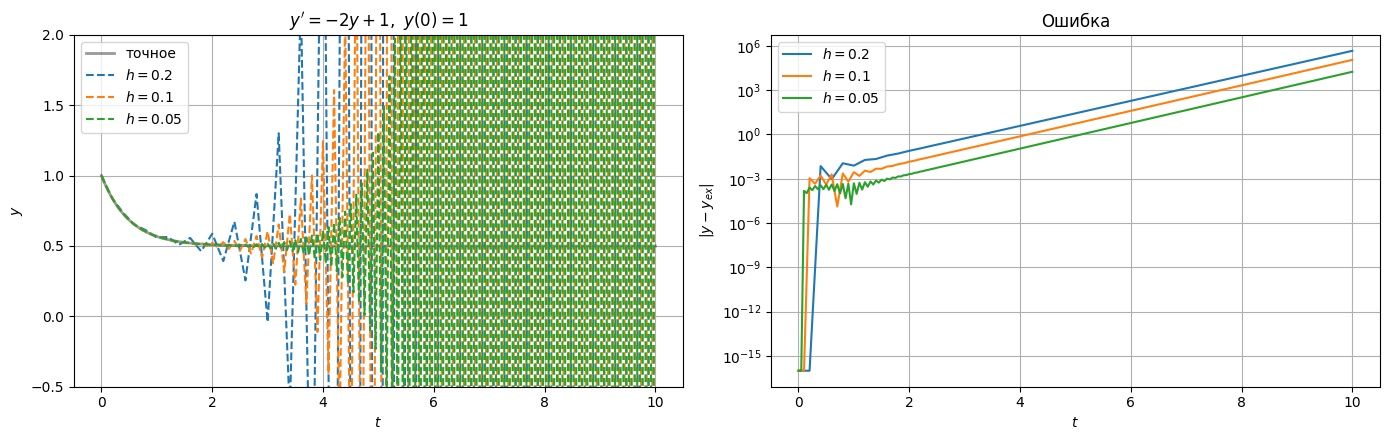

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
t_fine = np.linspace(0, 10, 500)
axes[0].plot(t_fine, 0.5 + 0.5 * np.exp(-2 * t_fine), "k-", lw=2, alpha=0.4, label="точное")

for h, (t, y) in zip(hs1, trajs1):
    axes[0].plot(t, y, "--", label=f"$h = {h}$")
    y_ex = 0.5 + 0.5 * np.exp(-2 * t)
    axes[1].semilogy(t, np.abs(y - y_ex) + 1e-16, label=f"$h = {h}$")

axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$y$")
axes[0].set_title(r"$y' = -2y + 1,\ y(0) = 1$")
axes[0].legend()
axes[0].grid()
axes[0].set_ylim(-0.5, 2.0)

axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$|y - y_{ex}|$")
axes[1].set_title("Ошибка")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

__Анализ результатов__

Заметим, что с определенного момента всегда начинаются быстрорастущие осцилляции. Попытаемся найти этому причину

Рассмотрим однородную часть $y_{n+1} + 4h\,y_n - y_{n-1} = 0$. 

Ее характеристическое уравнение $r^2 + 4h r - 1 = 0$ имеет корни $r_{1,2} = -2h \pm \sqrt{4h^2 + 1}$

Заметим, что $r_1 \approx 1 - 2h$ приближает решение в виде $e^{-2h}$.

С другой стороны $r_2 \approx -1 - 2h$, $|r_2| > 1 \ \forall h > 0$. Значит он будет порождать осцилляции которые мы видим. Заметим, что это согласуется с тем, что при меньших h осцилляции начинаются позже. Действительно, чем меньше $h,$ тем ближе $r_2$ к 1.

__Задача 2.__ (2 балла)

Получите численные решения следующей нелинейной краевой задачи при различных значениях параметра:

$$
\begin{aligned}
& y''+px\cos y=0, \quad 0<x\leq 1, \\
& y'(0)=0, \quad y(1)=0, \\
& p=1,4,7,15,25.
\end{aligned}
$$


__Решение__

В качестве сетки волзьмем $x_0 = 0 < x_1 < \dots < x_N = 1$ с шагом $h = 1/N$.

Разностная схема:

$$\frac{y_{i-1} - 2 y_i + y_{i+1}}{h^2} + p\,x_i\,\cos y_i = 0$$

В качестве начально приближения возьмем $\mathbf{y} \equiv 0$.

In [55]:
def solve_nonlinear_bvp(p, N, tol=1e-10, max_it=50):
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    y = np.zeros(N)
    for _ in range(max_it):
        y_full = np.concatenate([y, [0.0]])
        F = np.zeros(N)
        F[0] = 2 * (y_full[1] - y_full[0]) / h**2
        F[1:] = ((y_full[:-2] - 2*y_full[1:-1] + y_full[2:]) / h**2
                 + p * x[1:-1] * np.cos(y_full[1:-1]))

        main = np.empty(N)
        main[0] = -2 / h**2
        main[1:] = -2/h**2 - p * x[1:-1] * np.sin(y[1:])
        upper = np.full(N - 1, 1/h**2)
        upper[0] = 2 / h**2
        lower = np.full(N - 1, 1/h**2)

        ab = np.zeros((3, N))
        ab[0, 1:] = upper
        ab[1, :] = main
        ab[2, :-1] = lower
        delta = solve_banded((1, 1), ab, -F)
        y = y + delta
        if np.max(np.abs(delta)) < tol:
            break
    return x, np.concatenate([y, [0.0]])


N2 = 400
p_values = [1, 4, 7, 15, 25]
sols2 = [solve_nonlinear_bvp(p, N2) for p in p_values]

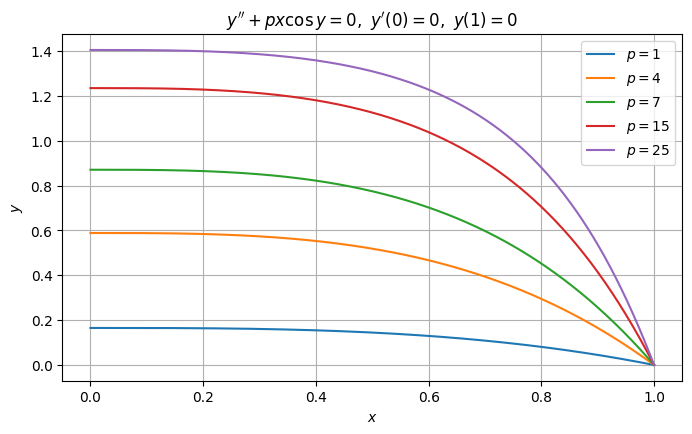

In [56]:
fig, ax = plt.subplots()
for p, (x_sol, y_sol) in zip(p_values, sols2):
    ax.plot(x_sol, y_sol, label=f"$p = {p}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(r"$y'' + p x \cos y = 0,\ y'(0) = 0,\ y(1) = 0$")
ax.legend()
ax.grid()
plt.show()

__Задача 3.__ (2 балла)

Решите следующее уравнение в частных производных конечно-разностной схемой. Постройте визуализацию решения и исследуйте сходимость на сгущающихся сетках, используя точное решение.

$$
\begin{aligned}
& u_t=\tfrac12 u_{xx}-e^{-t}(1+x), \quad 0 \leq x \leq 1, \quad 0<t\leq 1, \\
& u(0,t)=e^{-t}, \quad u(1,t)=2e^{-t}, \quad u(x,0)=1+x.
\end{aligned}
$$

Точное решение:

$$
u(x,t)=e^{-t}(1+x).
$$


__Решение__

Воспользуемся явной схемой:

$$u_j^{n+1} = u_j^n + \tau\left[\tfrac{1}{2}\,\frac{u_{j+1}^n - 2u_j^n + u_{j-1}^n}{h^2} - e^{-t^n}(1 + x_j)\right]$$

Мы уже показывали, что ее порядок аппроксимации $O(\tau + h^2)$

Условие устойчивости: $\tau \le h^2/(2 \cdot 0.5) = h^2$. Возьмем $\tau = 0.4\,h^2/0.5 = 0.8\,h^2$.

В этом случае $\tau \approx h^2$, а значит порядок аппроксимации можно оценить как $O(h^2)$

In [57]:
def solve_heat3(N, T=1.0, cfl=0.4):
    h = 1.0 / N
    tau = cfl * h**2 / 0.5
    Nt = int(np.ceil(T / tau))
    tau = T / Nt
    x = np.linspace(0, 1, N + 1)
    u = 1 + x
    for n in range(Nt):
        t_n = n * tau
        u_new = u.copy()
        u_new[1:-1] = (u[1:-1]
                      + tau * (0.5 * (u[2:] - 2*u[1:-1] + u[:-2]) / h**2
                               - np.exp(-t_n) * (1 + x[1:-1])))
        u_new[0] = np.exp(-(t_n + tau))
        u_new[-1] = 2 * np.exp(-(t_n + tau))
        u = u_new
    u_ex = np.exp(-T) * (1 + x)
    return x, u, u_ex


Ns_plot3 = [10, 40, 160]
sols3 = [solve_heat3(N) for N in Ns_plot3]

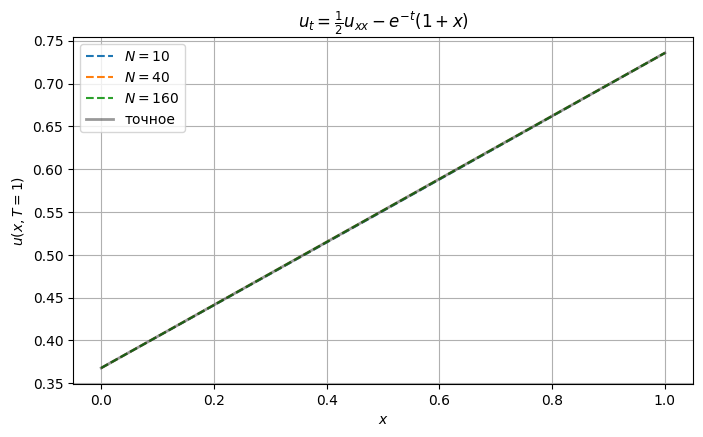

In [58]:
fig, ax = plt.subplots()
for N, (x, u, _) in zip(Ns_plot3, sols3):
    ax.plot(x, u, "--", label=f"$N = {N}$")
x_ref, _, u_ex_ref = sols3[-1]
ax.plot(x_ref, u_ex_ref, "k-", lw=2, alpha=0.4, label="точное")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x, T=1)$")
ax.set_title(r"$u_t = \frac{1}{2} u_{xx} - e^{-t}(1+x)$")
ax.legend()
ax.grid()
plt.show()

In [59]:
Ns3 = [10, 20, 40, 80, 160]
errs3 = []
for N in Ns3:
    _, u, u_ex = solve_heat3(N)
    err = np.max(np.abs(u - u_ex))
    errs3.append(err)
for i in range(1, len(Ns3)):
    rate = np.log2(errs3[i-1] / errs3[i])
    print(f"{Ns3[i-1]:3d} -> {Ns3[i]:3d}: порядок = {rate:.2f}")

 10 ->  20: порядок = 2.00
 20 ->  40: порядок = 2.00
 40 ->  80: порядок = 2.00
 80 -> 160: порядок = 2.00


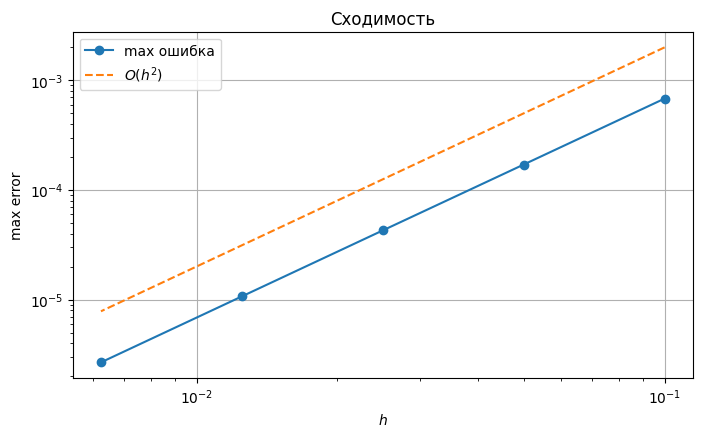

In [60]:
hs = 1 / np.array(Ns3)
fig, ax = plt.subplots()
ax.loglog(hs, errs3, "o-", label="max ошибка")
ax.loglog(hs, 0.2 * hs**2, "--", label=r"$O(h^2)$")
ax.set_xlabel("$h$")
ax.set_ylabel("max error")
ax.set_title("Сходимость")
ax.legend()
ax.grid()
plt.show()


__Задача 4.__ (1 балл)


Исследовать на устойчивость неявный метод Милна–Симпсона:

$$
3(y_{n+1} - y_{n-1}) = h(f_{n+1} + 2f_n + f_{n-1}).
$$

Применим схему к тестовому уравнению $y' = -y$ на отрезке $[0, T]$ с $y(0) = 1$ (точное решение $y_{\text{ex}}(t) = e^{-t}$) и исследуем численно поведение ошибки при измельчении шага $h$. Разрешая относительно $y_{n+1}$ при $f = -y$:

$$y_{n+1} = \dfrac{-2h\,y_n + (3 - h)\,y_{n-1}}{3 + h}$$

Стартовое значение $y_1 = e^{-h}$ берём из точного решения, $y_0 = 1$.

In [61]:
def scheme_problem(h, T=10.0):
    N = int(T / h)
    t = np.arange(N + 1) * h
    y = np.zeros(N + 1)
    y[0] = 1.0
    y[1] = np.exp(-h)
    for n in range(1, N):
        y[n + 1] = (-2 * h * y[n] + (3 - h) * y[n - 1]) / (3 + h)
    return t, y


hs4 = [0.4, 0.2, 0.1, 0.05, 0.025]
trajs4 = [scheme_problem(h) for h in hs4]

errs4 = []
for h, (t, y) in zip(hs4, trajs4):
    y_ex = np.exp(-t)
    err = np.max(np.abs(y - y_ex))
    errs4.append(err)
    print(f"h = {h:.4f},  max |y - y_ex| = {err:.4e}")

h = 0.4000,  max |y - y_ex| = 1.7526e-01
h = 0.2000,  max |y - y_ex| = 1.6414e-01
h = 0.1000,  max |y - y_ex| = 1.5672e-01
h = 0.0500,  max |y - y_ex| = 1.5258e-01
h = 0.0250,  max |y - y_ex| = 1.5041e-01


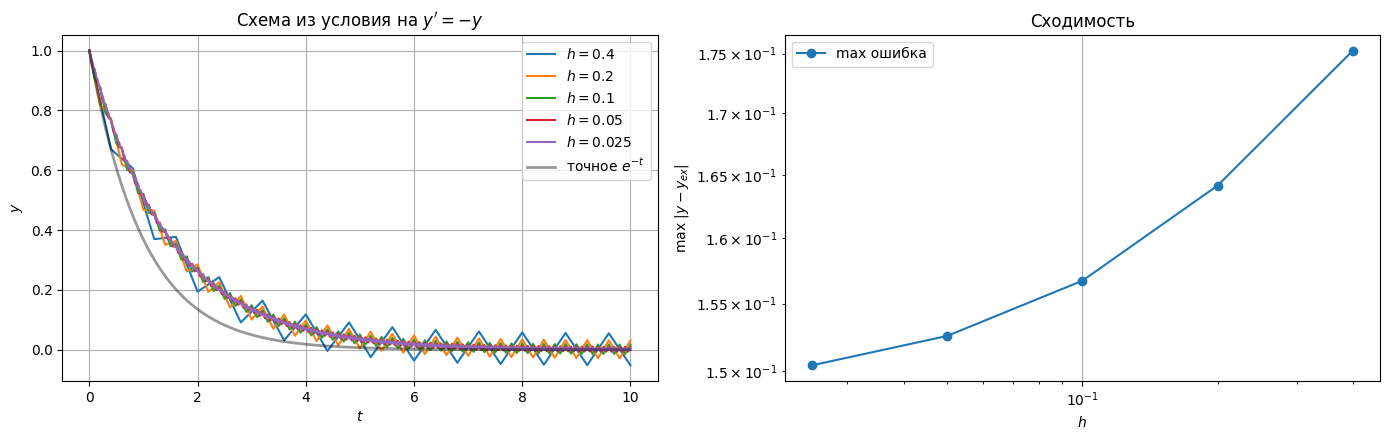

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for h, (t, y) in zip(hs4, trajs4):
    axes[0].plot(t, y, label=f"$h = {h}$")
t_plot = trajs4[-1][0]
axes[0].plot(t_plot, np.exp(-t_plot), "k-", lw=2, alpha=0.4, label="точное $e^{-t}$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$y$")
axes[0].set_title(r"Схема из условия на $y' = -y$")
axes[0].legend()
axes[0].grid()

axes[1].loglog(hs4, errs4, "o-", label="max ошибка")
axes[1].set_xlabel("$h$")
axes[1].set_ylabel(r"max $|y - y_{ex}|$")
axes[1].set_title("Сходимость")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


__Задача 5.__ (1 балл)

Определить параметры сетки для достижения точности $\varepsilon = 10^{-4}$ при численном решении задачи


$$
u_t = u_{xx} + \frac{4x}{x^2 + 2t + 1}\, u_x, \quad 0 \leq x \leq 1, \quad 0 < t,
$$
$$
u(0, t) = \frac{1}{2t + 1}, \quad u(1, t) = \frac{1}{2(t + 1)}, \quad 0 < t,
$$
$$
u(x, 0) = \frac{1}{x^2 + 1}, \quad 0 \leq x \leq 1,
$$


по явной схеме и найти это решение. Сравнить численное решение задачи с точным. Показать, что заданная точность достигнута.

Построим явную разностную схему с центральными разностями по $x$:

$$\frac{u_j^{n+1} - u_j^n}{\tau} = \frac{u_{j+1}^n - 2u_j^n + u_{j-1}^n}{h^2} + a(x_j, t^n)\,\frac{u_{j+1}^n - u_{j-1}^n}{2h}, \qquad a(x,t) = \frac{4x}{x^2 + 2t + 1}$$

Порядок аппроксимации: $O(\tau + h^2)$. Условие устойчивости по диффузии: $\tau \le h^2/2$.

Точное решение нашего уравнения: $u(x, t) = \dfrac{1}{x^2 + 2t + 1}$.

Для точности $\varepsilon = 10^{-4}$ достаточно $h^2 \sim 10^{-4}$, т.е. $h \sim 10^{-2}$; тогда $\tau \le h^2/2 \sim 5\cdot 10^{-5}$. Итого возьмем $N = 100$, $\tau = 0.4\, h^2 = 4\cdot 10^{-5}$.

In [63]:
def solve_task5(N, tau, T=1.0):
    h = 1.0 / N
    Nt = int(np.ceil(T / tau))
    tau = T / Nt
    x = np.linspace(0, 1, N + 1)
    u = 1.0 / (x**2 + 1)
    for n in range(Nt):
        t_n = n * tau
        a_coef = 4 * x[1:-1] / (x[1:-1]**2 + 2 * t_n + 1)
        u_new = u.copy()
        u_new[1:-1] = (u[1:-1]
                       + tau * (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2
                       + tau * a_coef * (u[2:] - u[:-2]) / (2 * h))
        u_new[0] = 1.0 / (2 * (t_n + tau) + 1)
        u_new[-1] = 1.0 / (2 * ((t_n + tau) + 1))
        u = u_new
    u_ex = 1.0 / (x**2 + 2 * T + 1)
    return x, u, u_ex


N5 = 100
h5 = 1.0 / N5
tau5 = 0.4 * h5**2
x5, u5, u5_ex = solve_task5(N5, tau5)

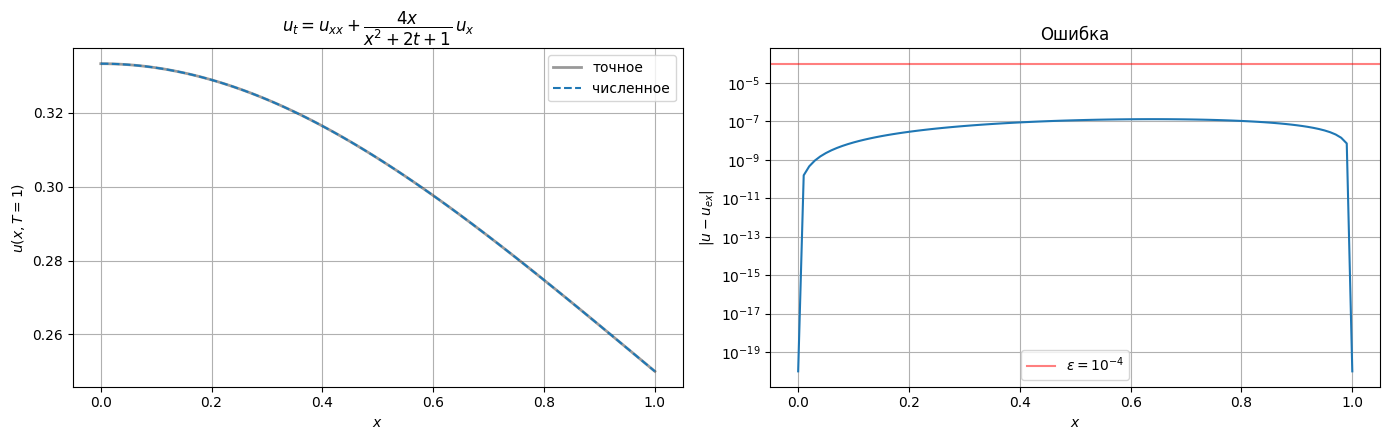

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(x5, u5_ex, "k-", lw=2, alpha=0.4, label="точное")
axes[0].plot(x5, u5, "--", label="численное")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$u(x, T=1)$")
axes[0].set_title(r"$u_t = u_{xx} + \dfrac{4x}{x^2 + 2t + 1}\, u_x$")
axes[0].legend()
axes[0].grid()

axes[1].semilogy(x5, np.abs(u5 - u5_ex) + 1e-20)
axes[1].axhline(1e-4, color="r", alpha=0.5, label=r"$\varepsilon = 10^{-4}$")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel(r"$|u - u_{ex}|$")
axes[1].set_title("Ошибка")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

На графике видно, что численное решение совпадает с точным визуально, а максимальная поточечная ошибка всюду ниже пороговой линии $\varepsilon = 10^{-4}$. Таким образом, выбранные параметры $h = 10^{-2}$, $\tau = 4\cdot 10^{-5}$ действительно обеспечивают требуемую точность.



__Задача 6.__ (2 балла)

МКЭ: расписать получение слабой постановки задачи, базовые функции и получение матриц.


$$a\frac{d^2u}{dx^2}+cu(x)=f(x)$$
$$u(x_0)=u_0,  x_0\leq x\leq L$$
$$a\frac{du}{dx}(L)= e$$



$$a=b=c=1, f(x)=sinxcosx, x_0=0, u_0=1, L=10, e = 1$$

### Слабая постановка

Вводим пространство пробных функций $V = \{u \in H^1(x_0, L) : u(x_0) = u_0\}$ и пространство тестовых функций $V_0 = \{v \in H^1(x_0, L) : v(x_0) = 0\}$.

Умножаем уравнение на $v \in V_0$ и интегрируем по $[x_0, L]$:

$$\int_{x_0}^L (a\,u'' + c\,u)\, v\, dx = \int_{x_0}^L f v\, dx$$

Интегрируем по частям слагаемое с $u''$:

$$\int_{x_0}^L a\,u'' v\, dx = \bigl[a\,u' v\bigr]_{x_0}^{L} - \int_{x_0}^L a\,u' v'\, dx$$

На левой границе $v(x_0) = 0$, на правой $a\,u'(L) = e$, поэтому

$$\bigl[a\,u' v\bigr]_{x_0}^{L} = a\,u'(L)\, v(L) = e\,v(L)$$

Подставляя обратно:

$$-\int_{x_0}^L a\,u' v'\, dx + e\,v(L) + \int_{x_0}^L c\,u\, v\, dx = \int_{x_0}^L f v\, dx$$

Перенося неизвестное $u$ в левую часть:

$$\int_{x_0}^L \bigl(a\,u' v' - c\,u v\bigr) dx = -\int_{x_0}^L f v\, dx + e\,v(L)$$

Обозначим билинейную форму и линейный функционал:

$$\mathcal{A}(u, v) = \int_{x_0}^L \bigl(a\,u' v' - c\,u v\bigr) dx, \qquad \ell(v) = -\int_{x_0}^L f v\, dx + e\,v(L)$$


### Базисные функции

Разбиваем $[x_0, L]$ на $N$ равных элементов шага $h = (L - x_0)/N$: узлы $\xi_i = x_0 + i h$, $i = 0, 1, \dots, N$.

Используем линейные (шляпные) базисные функции $\phi_i(x)$, равные $1$ в узле $\xi_i$ и $0$ во всех остальных узлах, линейные между соседями:

$$\phi_i(x) = \begin{cases}
(x - \xi_{i-1})/h, & x \in [\xi_{i-1}, \xi_i] \\
(\xi_{i+1} - x)/h, & x \in [\xi_i, \xi_{i+1}] \\
0, & \text{иначе}
\end{cases}$$

Приближённое решение ищем в виде

$$u_h(x) = \sum_{j=0}^{N} U_j\, \phi_j(x), \quad U_0 = u_0$$

Тестовые функции: $v = \phi_i$ для $i = 1, \dots, N$ (то есть $\phi_i(x_0) = 0$).

### Матрицы и вектор правой части

Подставляем $u_h$ в $\mathcal{A}(u_h, \phi_i) = \ell(\phi_i)$:

$$\sum_{j=0}^{N} U_j\, \mathcal{A}(\phi_j, \phi_i) = \ell(\phi_i), \quad i = 1, \dots, N$$

Обозначим $K_{ij} = \mathcal{A}(\phi_j, \phi_i)$, $F_i = \ell(\phi_i)$. Получаем линейную систему

$$K\,\mathbf{U} = \mathbf{F}$$

На одном элементе $[\xi_e, \xi_{e+1}]$ длины $h$ функции имеют производные $\mp 1/h$. Нужны два базовых интеграла:

Матрица $\int \phi_j' \phi_i'$:

$$S^e = \dfrac{1}{h}\begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix}$$

Матрица $\int \phi_j \phi_i$:

$$M^e = \dfrac{h}{6}\begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$$

Собирая все вместе:\

$$K^e = a\,S^e - c\,M^e = \frac{1}{h}\begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix} - \frac{h}{6}\begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$$

Элемент вектора левой части:

$$F^e_i = -\int_{\xi_e}^{\xi_{e+1}} f(x)\,\phi_i(x)\, dx$$

Для $f(x) = \tfrac{1}{2}\sin(2x)$ интеграл берётся либо аналитически, либо квадратурой Гаусса.

Граничный член от Неймана добавляется только к последнему узлу: $F_N \mathrel{+}= e = 1$.